## Importação de Dependências e Configurações

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scripts.outliers import outlier_iqr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') # Com separador de milhar

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

## Análise inicial dos arquivos

In [51]:
df_vendas = pd.read_csv('..\\data\\projeto_02_ecommerce_vendas.csv')
df_vendedor = pd.read_csv('..\\data\\projeto_02_vendedores_perfil.csv')
df_aval_sus = pd.read_csv('..\\data\\projeto_02_avaliacoes_suspeitas.csv')

In [52]:
print('Informações Iniciais dos DataFrames -- Vendas')
print('--'*100)
print(df_vendas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   str    
 1   data_pedido     8000 non-null   str    
 2   hora_pedido     8000 non-null   str    
 3   vendedor_id     8000 non-null   str    
 4   categoria       8000 non-null   str    
 5   produto_id      8000 non-null   str    
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   str    
 11  status_pedido   8000 non-null   str    
 12  nota_avaliacao  5023 n

In [53]:
print('--'*100)
print('Informações Iniciais dos DataFrames -- Vendedores')
print(df_vendedor.info())

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Informações Iniciais dos DataFrames -- Vendedores
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    str    
 1   nome_loja            120 non-null    str    
 2   data_cadastro        120 non-null    str    
 3   cidade               120 non-null    str    
 4   estado               120 non-null    str    
 5   categoria_principal  120 non-null    str    
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), str(6)
memory us

In [54]:
print('--'*100)
print('Informações Iniciais dos DataFrames -- Avaliações suspeitas')
print(df_aval_sus.info())

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Informações Iniciais dos DataFrames -- Avaliações suspeitas
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   avaliacao_id        3000 non-null   str  
 1   vendedor_id         3000 non-null   str  
 2   comprador_id        3000 non-null   str  
 3   data_avaliacao      3000 non-null   str  
 4   data_criacao_conta  3000 non-null   str  
 5   nota                3000 non-null   int64
 6   ip_origem           3000 non-null   str  
 7   texto_avaliacao     2668 non-null   str  
dtypes: int64(1), str(7)
memory usage: 187.6 KB
None


## Transformando dados

In [55]:
for col in df_vendas.columns:
    print(col)
    print(np.sort(df_vendas[col].unique().tolist()))
    print('\n\n')

pedido_id
['PED-000001' 'PED-000002' 'PED-000003' ... 'PED-007998' 'PED-007999'
 'PED-008000']



data_pedido
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31' '2023-02-01' '2023-02-02' '2023-02-03' '2023-02-04'
 '2023-02-05' '2023-02-06' '2023-02-07' '2023-02-08' '2023-02-09'
 '2023-02-10' '2023-02-11' '2023-02-12' '2023-02-13' '2023-02-14'
 '2023-02-15' '2023-02-16' '2023-02-17' '2023-02-18' '2023-02-19'
 '2023-02-20' '2023-02-21' '2023-02-22' '2023-02-23' '2023-02-24'
 '2023-02-25' '2023-02-26' '2023-02-27' '2023-02-28' '2023-03-01'
 '2023-03-02' '2023-03-03' '2023-03-04' '2023-03-05' '2023-03-06'
 '2023-03-07' '2023-03-08' '2023

In [56]:
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido_dt'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')
df_vendas['frete'] = pd.to_numeric(df_vendas['frete']).fillna(0)
df_vendas['nota_avaliacao'] = df_vendas['nota_avaliacao'].fillna(0)

In [57]:
for col in df_vendedor.columns:
    print(col)
    print(np.sort(df_vendedor[col].unique()))
    print('\n\n')

vendedor_id
['VEND-0001' 'VEND-0002' 'VEND-0003' 'VEND-0004' 'VEND-0005' 'VEND-0006'
 'VEND-0007' 'VEND-0008' 'VEND-0009' 'VEND-0010' 'VEND-0011' 'VEND-0012'
 'VEND-0013' 'VEND-0014' 'VEND-0015' 'VEND-0016' 'VEND-0017' 'VEND-0018'
 'VEND-0019' 'VEND-0020' 'VEND-0021' 'VEND-0022' 'VEND-0023' 'VEND-0024'
 'VEND-0025' 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0030'
 'VEND-0031' 'VEND-0032' 'VEND-0033' 'VEND-0034' 'VEND-0035' 'VEND-0036'
 'VEND-0037' 'VEND-0038' 'VEND-0039' 'VEND-0040' 'VEND-0041' 'VEND-0042'
 'VEND-0043' 'VEND-0044' 'VEND-0045' 'VEND-0046' 'VEND-0047' 'VEND-0048'
 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0052' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0056' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060'
 'VEND-0061' 'VEND-0062' 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0066'
 'VEND-0067' 'VEND-0068' 'VEND-0069' 'VEND-0070' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0076' 'VEND-0077' 'VEND-0078'
 'VEND-0079' 'VEND-0080' 'VEND-0081' 'V

In [58]:
df_vendedor['_data_cadastro_dt'] = pd.to_datetime(
    df_vendedor['data_cadastro'],  format='%Y-%m-%d')

In [59]:
for col in df_aval_sus.columns:
    print(col)
    if col != "texto_avaliacao":
        print(np.sort(df_aval_sus[col].unique()))
    else:
        print(df_aval_sus[col].drop_duplicates().sort_values())
    print('\n\n')

avaliacao_id
['AVAL-00001' 'AVAL-00002' 'AVAL-00003' ... 'AVAL-02998' 'AVAL-02999'
 'AVAL-03000']



vendedor_id
['VEND-0001' 'VEND-0002' 'VEND-0003' 'VEND-0004' 'VEND-0005' 'VEND-0006'
 'VEND-0007' 'VEND-0008' 'VEND-0009' 'VEND-0010' 'VEND-0011' 'VEND-0012'
 'VEND-0013' 'VEND-0014' 'VEND-0015' 'VEND-0016' 'VEND-0017' 'VEND-0018'
 'VEND-0019' 'VEND-0020' 'VEND-0021' 'VEND-0022' 'VEND-0023' 'VEND-0024'
 'VEND-0025' 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0030'
 'VEND-0031' 'VEND-0032' 'VEND-0033' 'VEND-0034' 'VEND-0035' 'VEND-0036'
 'VEND-0037' 'VEND-0038' 'VEND-0039' 'VEND-0040' 'VEND-0041' 'VEND-0042'
 'VEND-0043' 'VEND-0044' 'VEND-0045' 'VEND-0046' 'VEND-0047' 'VEND-0048'
 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0052' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0056' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060'
 'VEND-0061' 'VEND-0062' 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0066'
 'VEND-0067' 'VEND-0068' 'VEND-0069' 'VEND-0070' 'VEND-0071' 'VEND-0072'
 'VEND-0073

In [60]:
df_aval_sus['_data_avaliacao_dt'] = pd.to_datetime(
    df_aval_sus['data_avaliacao'], format='%Y-%m-%d')

df_aval_sus['_data_criacao_conta_dt'] = pd.to_datetime(
    df_aval_sus['data_criacao_conta'], format='%Y-%m-%d')

df_aval_sus['texto_avaliacao'] = df_aval_sus['texto_avaliacao'].fillna(
    'Sem Comentário Escrito')

## Detecção de duplicatas

In [61]:
dup_vendas_pedido = df_vendas.duplicated(subset=['pedido_id']).sum()
dup_vendas_item = df_vendas.duplicated(subset=['pedido_id', 'produto_id']).sum()
print('VENDAS')
print(f'  Linhas duplicadas por pedido_id: {dup_vendas_pedido}')
print(f'  Linhas duplicadas por (pedido_id, produto_id): {dup_vendas_item}')
if dup_vendas_item > 0:
    n_antes = len(df_vendas)
    df_vendas = df_vendas.drop_duplicates(subset=['pedido_id', 'produto_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendas)} duplicatas. Total de linhas: {len(df_vendas)}')

VENDAS
  Linhas duplicadas por pedido_id: 0
  Linhas duplicadas por (pedido_id, produto_id): 0


In [62]:
dup_vendedor = df_vendedor.duplicated(subset=['vendedor_id']).sum()
print('VENDEDORES')
print(f'  Linhas duplicadas por vendedor_id: {dup_vendedor}')
if dup_vendedor > 0:
    n_antes = len(df_vendedor)
    df_vendedor = df_vendedor.drop_duplicates(subset=['vendedor_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendedor)} duplicatas. Total de linhas: {len(df_vendedor)}')
print()

VENDEDORES
  Linhas duplicadas por vendedor_id: 0



In [63]:
dup_aval_id = df_aval_sus.duplicated(subset=['avaliacao_id']).sum()
dup_aval_multi = df_aval_sus.duplicated(subset=['vendedor_id', 'comprador_id', 'data_avaliacao']).sum()
print('AVALIAÇÕES SUSPEITAS')
print(f'  Linhas duplicadas por avaliacao_id: {dup_aval_id}')
print(f'  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): {dup_aval_multi}')
if dup_aval_id > 0:
    n_antes = len(df_aval_sus)
    df_aval_sus = df_aval_sus.drop_duplicates(subset=['avaliacao_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_aval_sus)} duplicatas por avaliacao_id. Total de linhas: {len(df_aval_sus)}')

AVALIAÇÕES SUSPEITAS
  Linhas duplicadas por avaliacao_id: 0
  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): 0


## Investigações base

---
### **Distribuição entre tipos de vendedores: Verificados e Não Verificados**

In [64]:
df_vendedor['verificado'].value_counts(normalize='percent')

verificado
False   0.53
True    0.47
Name: proportion, dtype: float64

In [65]:
verificados = df_vendedor.query('verificado == True')
n_verificados = df_vendedor.query('verificado == False')

print('Verificados:')
print(verificados['vendedor_id'].unique())
print('---'*100)

print('Não Verificados:')
print(n_verificados['vendedor_id'].unique())

Verificados:
<StringArray>
['VEND-0003', 'VEND-0006', 'VEND-0007', 'VEND-0009', 'VEND-0010', 'VEND-0015',
 'VEND-0016', 'VEND-0018', 'VEND-0019', 'VEND-0020', 'VEND-0022', 'VEND-0025',
 'VEND-0026', 'VEND-0027', 'VEND-0028', 'VEND-0029', 'VEND-0032', 'VEND-0041',
 'VEND-0047', 'VEND-0049', 'VEND-0050', 'VEND-0051', 'VEND-0053', 'VEND-0054',
 'VEND-0055', 'VEND-0057', 'VEND-0058', 'VEND-0059', 'VEND-0060', 'VEND-0062',
 'VEND-0063', 'VEND-0064', 'VEND-0065', 'VEND-0067', 'VEND-0071', 'VEND-0072',
 'VEND-0073', 'VEND-0074', 'VEND-0075', 'VEND-0077', 'VEND-0084', 'VEND-0085',
 'VEND-0086', 'VEND-0091', 'VEND-0092', 'VEND-0096', 'VEND-0098', 'VEND-0100',
 'VEND-0103', 'VEND-0107', 'VEND-0108', 'VEND-0109', 'VEND-0111', 'VEND-0112',
 'VEND-0116', 'VEND-0117', 'VEND-0118']
Length: 57, dtype: str
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Conclusão**: Não há uma sobreposição muito significativa da quantidade de `verificados` e `não verificados` e não há repetição de `vendedor_id` em categorias distintas

### **Verificação de vendas**

In [66]:
df_vendas_merged = df_vendas.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id')
df_vendas_merged

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,0.00,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,0.00,2023-10-21,1900-01-01 16:01:00,False
3,PED-000004,2023-10-29,18:53,VEND-0083,Eletrônicos,PROD-0282,620.43,2,"1,240.86",10.89,MG,Entregue,5.00,2023-10-29,1900-01-01 18:53:00,False
4,PED-000005,2024-03-21,09:13,VEND-0025,Acessórios,PROD-0141,36.96,1,36.96,35.60,MA,Entregue,4.00,2024-03-21,1900-01-01 09:13:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,PED-007996,2024-07-29,12:33,VEND-0058,Acessórios,PROD-0359,78.62,1,78.62,19.67,CE,Cancelado,0.00,2024-07-29,1900-01-01 12:33:00,True
7996,PED-007997,2024-04-11,06:56,VEND-0039,Moda Feminina,PROD-0025,121.46,3,364.38,40.36,PE,Entregue,3.00,2024-04-11,1900-01-01 06:56:00,False
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.00,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False


In [67]:
df_vendas_merged.columns

Index(['pedido_id', 'data_pedido', 'hora_pedido', 'vendedor_id', 'categoria',
       'produto_id', 'preco_unitario', 'quantidade', 'valor_total', 'frete',
       'estado_cliente', 'status_pedido', 'nota_avaliacao', '_data_pedido_dt',
       '_hora_pedido_dt', 'verificado'],
      dtype='str')

In [68]:
valor_total_incorreto = df_vendas_merged[
    (df_vendas_merged['preco_unitario'] * df_vendas_merged['quantidade']) != df_vendas_merged['valor_total']
]

valor_total_incorreto

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
12,PED-000013,2023-09-20,08:44,VEND-0029,Infantil,PROD-0252,101.92,2,203.85,18.88,RS,Entregue,5.00,2023-09-20,1900-01-01 08:44:00,True
22,PED-000023,2023-09-12,12:02,VEND-0063,Esporte & Lazer,PROD-0032,234.61,2,469.23,10.73,CE,Cancelado,0.00,2023-09-12,1900-01-01 12:02:00,True
23,PED-000024,2024-02-18,06:28,VEND-0120,Casa & Decoração,PROD-0033,253.16,2,506.33,42.73,CE,Entregue,5.00,2024-02-18,1900-01-01 06:28:00,False
25,PED-000026,2024-03-06,04:15,VEND-0099,Eletrônicos,PROD-0331,535.58,3,"1,606.73",41.12,PB,Entregue,4.00,2024-03-06,1900-01-01 04:15:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,PED-007968,2023-12-12,12:34,VEND-0083,Esporte & Lazer,PROD-0290,159.50,3,478.49,34.98,PR,Devolvido,0.00,2023-12-12,1900-01-01 12:34:00,False
7975,PED-007976,2024-06-01,15:23,VEND-0035,Esporte & Lazer,PROD-0410,194.09,2,388.17,36.39,RS,Devolvido,0.00,2024-06-01,1900-01-01 15:23:00,False
7978,PED-007979,2024-01-31,18:43,VEND-0013,Infantil,PROD-0390,109.19,3,327.56,23.56,BA,Cancelado,0.00,2024-01-31,1900-01-01 18:43:00,False
7992,PED-007993,2023-03-20,18:51,VEND-0096,Moda Feminina,PROD-0431,62.23,2,124.45,27.18,CE,Entregue,5.00,2023-03-20,1900-01-01 18:51:00,True


In [69]:
valor_total_incorreto['verificado'].value_counts(normalize=True)

verificado
False   0.54
True    0.46
Name: proportion, dtype: float64

**PONTO DE ATENÇÃO**: 

- Há casos em que o valor total da venda está incorreto e que o frete é desconsiderado do cálculo independente da presença do frete e independente do fato de ser verificado ou não.

- Verificar qual a razão por trás disso



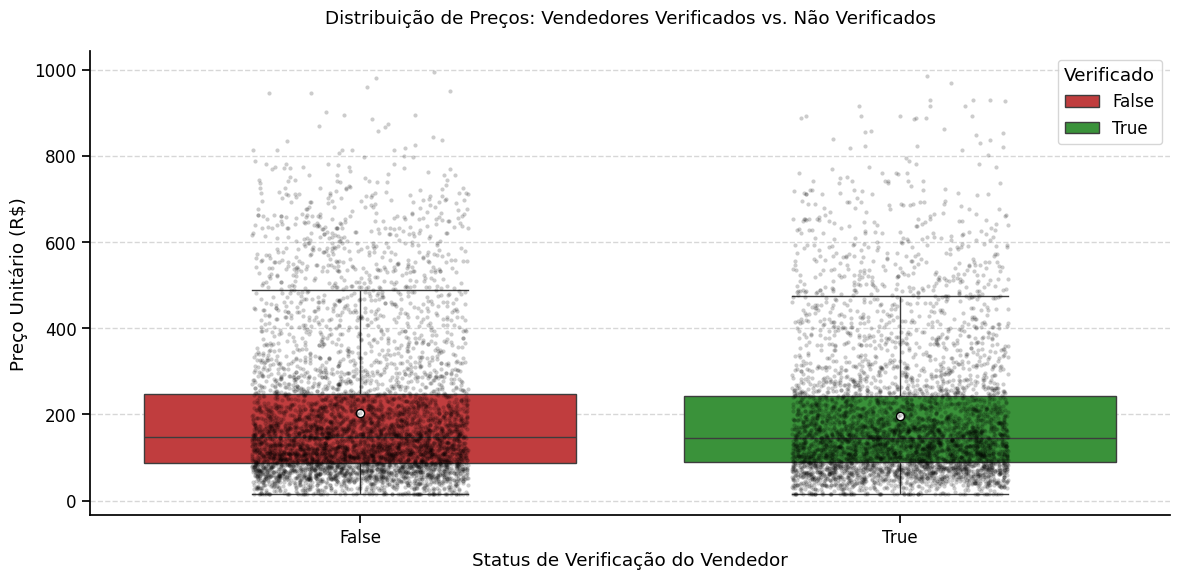

In [70]:
df_expandido = df_vendas_merged.loc[df_vendas_merged.index.repeat(df_vendas_merged['quantidade'])]

plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_expandido, 
    x='verificado', 
    y='preco_unitario', 
    color='black', 
    alpha=0.2,
    jitter=0.2,
    size=3
)

plt.title('Distribuição de Preços: Vendedores Verificados vs. Não Verificados', pad=20)
plt.xlabel('Status de Verificação do Vendedor')
plt.ylabel('Preço Unitário (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

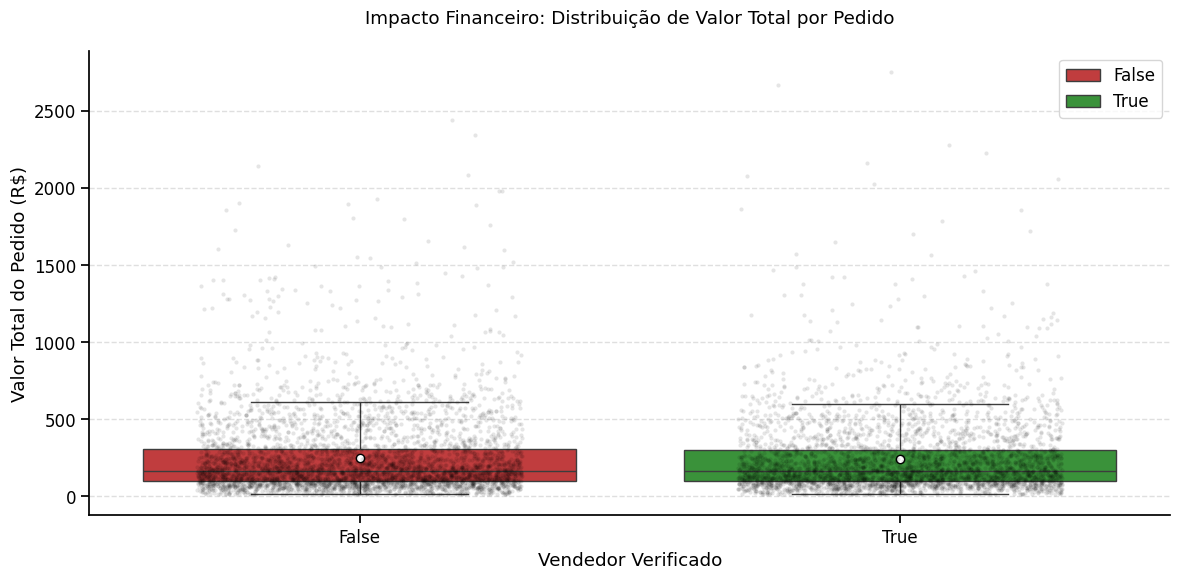

In [71]:
plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='valor_total',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged, 
    x='verificado', 
    y='valor_total', 
    color='black', 
    alpha=0.1,
    jitter=0.3,
    size=3
)

plt.title('Impacto Financeiro: Distribuição de Valor Total por Pedido', pad=20)
plt.xlabel('Vendedor Verificado')
plt.ylabel('Valor Total do Pedido (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

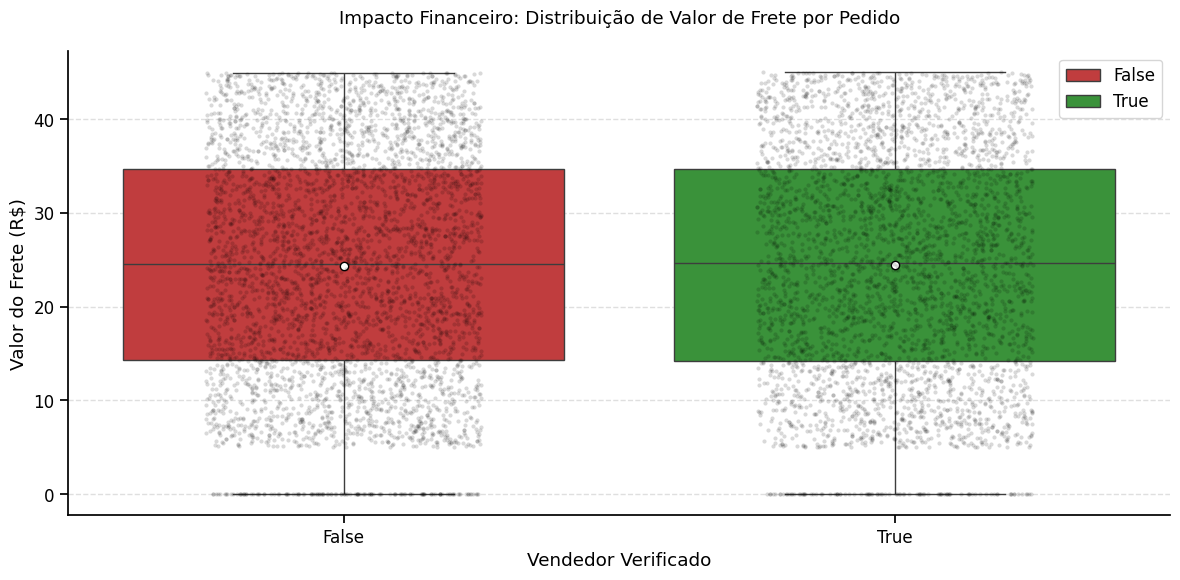

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='frete',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged, 
    x='verificado', 
    y='frete', 
    color='black', 
    alpha=0.15,
    jitter=0.25,
    size=3
)

plt.title('Impacto Financeiro: Distribuição de Valor de Frete por Pedido', pad=20)
plt.xlabel('Vendedor Verificado')
plt.ylabel('Valor do Frete (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

In [73]:
df_vendas_merged_clean_vt, outliers_vendas = outlier_iqr(df_vendas_merged, 'valor_total')
df_expandido_vt, outliers_expandido = outlier_iqr(df_expandido, 'preco_unitario')
df_vendas_merged_clean_frete, outliers_vendas = outlier_iqr(df_vendas_merged, 'frete')

Coluna: valor_total
Outliers removidos: 587
Limites: -207.35 a 608.93

Coluna: preco_unitario
Outliers removidos: 849
Limites: -149.40 a 483.82

Coluna: frete
Outliers removidos: 0
Limites: -16.23 a 65.24



In [ ]:
estao_presentes = df_vendas_merged_clean_vt.index.isin(df_expandido_vt.index).all()

if estao_presentes:
    print("✅ Sucesso: Todos os registros do DF limpo estão no DF expandido.")
else:
    print("❌ Atenção: Alguns registros do DF limpo não foram encontrados no expandido.")

❌ Atenção: Alguns registros do DF limpo não foram encontrados no expandido.


In [102]:
ids_limpos = set(df_vendas_merged_clean_vt['pedido_id'])
ids_expandidos = set(df_expandido_vt['pedido_id'])

faltantes = ids_limpos - ids_expandidos

if not faltantes:
    print("✅ Todos os pedido_id estão presentes.")
else:
    print(f"❌ Faltam {len(faltantes)} pedidos no DataFrame expandido.")

❌ Faltam 308 pedidos no DataFrame expandido.


In [103]:
indices_outliers_vt = outliers_vendas.index
indices_outliers_pu = outliers_expandido.index
todos_indices_para_remover = set(indices_outliers_vt).union(set(indices_outliers_pu))

# Limpando o DataFrame Original
df_vendas_merged_final = df_vendas_merged.drop(index=todos_indices_para_remover, errors='ignore')

# Limpando o DataFrame Expandido
df_expandido_final = df_expandido.drop(index=todos_indices_para_remover, errors='ignore')

In [104]:
df_vendas_merged_final

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,0.00,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,0.00,2023-10-21,1900-01-01 16:01:00,False
4,PED-000005,2024-03-21,09:13,VEND-0025,Acessórios,PROD-0141,36.96,1,36.96,35.60,MA,Entregue,4.00,2024-03-21,1900-01-01 09:13:00,True
5,PED-000006,2023-04-23,15:13,VEND-0053,Eletrônicos,PROD-0296,276.97,1,276.97,14.28,RJ,Entregue,4.00,2023-04-23,1900-01-01 15:13:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,PED-007996,2024-07-29,12:33,VEND-0058,Acessórios,PROD-0359,78.62,1,78.62,19.67,CE,Cancelado,0.00,2024-07-29,1900-01-01 12:33:00,True
7996,PED-007997,2024-04-11,06:56,VEND-0039,Moda Feminina,PROD-0025,121.46,3,364.38,40.36,PE,Entregue,3.00,2024-04-11,1900-01-01 06:56:00,False
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.00,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False


In [105]:
df_expandido_final

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,0.00,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,0.00,2023-10-21,1900-01-01 16:01:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.00,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False


---
### 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

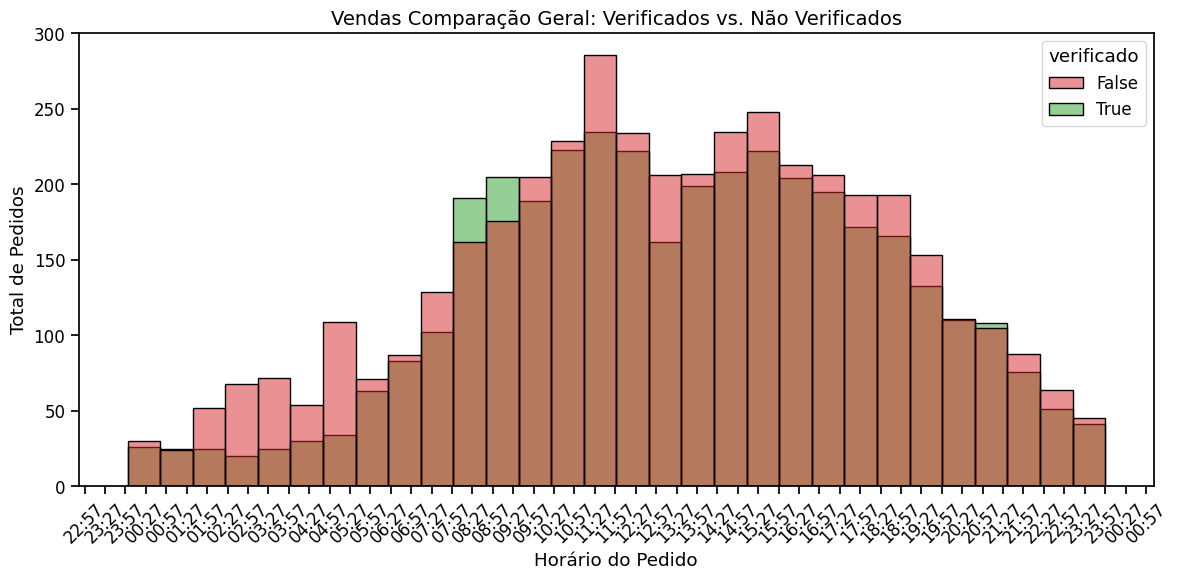

In [75]:
vendas_com_status_geral = df_vendas.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status_geral, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas Comparação Geral: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

In [76]:
vendas_2_5_am = df_vendas.query('_hora_pedido_dt.dt.hour >= 2 and _hora_pedido_dt.dt.hour <= 5')
vendas_2_5_am

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt
14,PED-000015,2023-01-13,05:43,VEND-0043,Casa & Decoração,PROD-0030,393.71,1,393.71,32.76,CE,Devolvido,0.00,2023-01-13,1900-01-01 05:43:00
25,PED-000026,2024-03-06,04:15,VEND-0099,Eletrônicos,PROD-0331,535.58,3,"1,606.73",41.12,PB,Entregue,4.00,2024-03-06,1900-01-01 04:15:00
66,PED-000067,2023-07-10,04:27,VEND-0010,Moda Feminina,PROD-0016,150.14,1,150.14,44.67,CE,Entregue,5.00,2023-07-10,1900-01-01 04:27:00
97,PED-000098,2023-07-24,03:41,VEND-0042,Esporte & Lazer,PROD-0305,189.20,2,378.39,26.38,CE,Entregue,5.00,2023-07-24,1900-01-01 03:41:00
100,PED-000101,2023-08-16,04:02,VEND-0045,Moda Masculina,PROD-0033,161.69,2,323.38,25.42,CE,Em trânsito,0.00,2023-08-16,1900-01-01 04:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7945,PED-007946,2023-02-02,02:30,VEND-0042,Esporte & Lazer,PROD-0377,107.73,2,215.45,35.51,SP,Entregue,5.00,2023-02-02,1900-01-01 02:30:00
7947,PED-007948,2023-09-13,03:07,VEND-0020,Eletrônicos,PROD-0080,536.33,1,536.33,44.98,MG,Cancelado,0.00,2023-09-13,1900-01-01 03:07:00
7962,PED-007963,2023-09-04,04:59,VEND-0043,Moda Masculina,PROD-0036,168.83,1,168.83,33.54,CE,Entregue,4.00,2023-09-04,1900-01-01 04:59:00
7973,PED-007974,2024-08-13,02:06,VEND-0106,Moda Masculina,PROD-0333,134.61,1,134.61,40.51,RJ,Devolvido,0.00,2024-08-13,1900-01-01 02:06:00


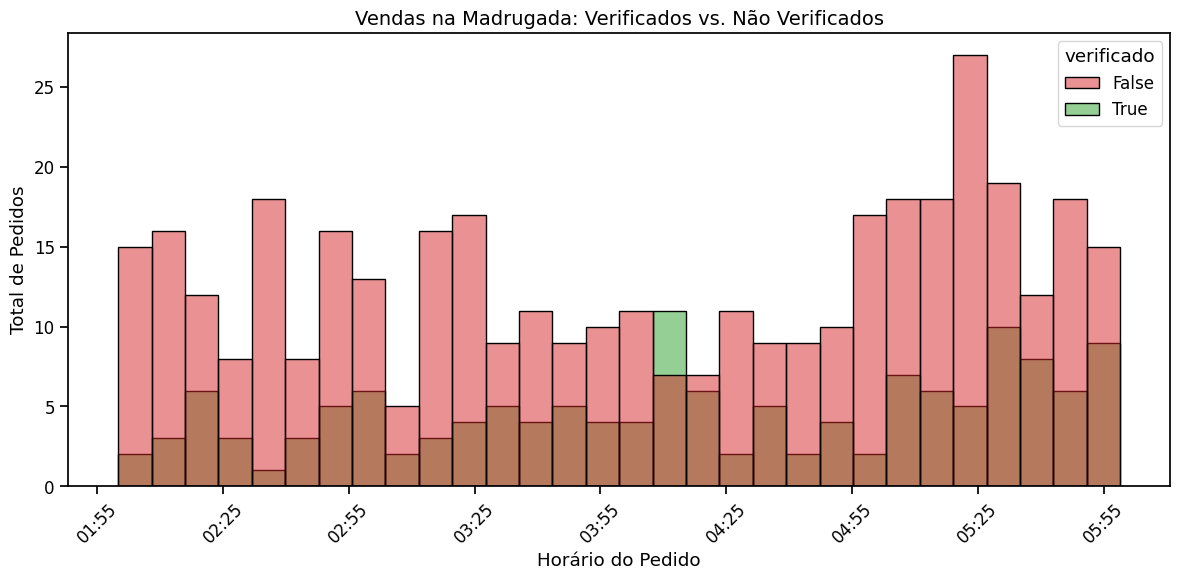

In [77]:
vendas_com_status = vendas_2_5_am.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'}, # Verde para Verificado, Vermelho para Não
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas na Madrugada: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

**Conclusões**
- Em comparação ao horário das 8:00 ao 12:00 é quase irrelevante, melhor esperar para ver novas informações.

- Ainda que seja visível que vendas dos não verificados é maior é melhor considerar como um ponto futuro de análise

---
### 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

In [78]:
df_aval_sus['tempo_criacao_conta_dias'] = (df_aval_sus['_data_avaliacao_dt'] - df_aval_sus['_data_criacao_conta_dt']).dt.days
df_aval_sus_info = df_aval_sus.merge(df_vendedor, on='vendedor_id', how='left')

df_aval_sus_info

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,_data_avaliacao_dt,_data_criacao_conta_dt,tempo_criacao_conta_dias,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,378,Loja EPNPN,2022-03-05,Salvador,PE,Casa & Decoração,1575,2.90,23,True,2022-03-05
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,277,Loja TTRVV,2021-12-30,Belo Horizonte,MA,Acessórios,1107,4.30,26,True,2021-12-30
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,189,Loja VLJBA,2020-11-25,Manaus,MG,Eletrônicos,278,3.80,10,True,2020-11-25
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,356,Loja ZANLX,2020-09-10,Porto Alegre,MG,Esporte & Lazer,1765,4.30,18,False,2020-09-10
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,412,Loja AFRXX,2020-05-25,Brasília,RJ,Infantil,204,4.50,16,True,2020-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,Sem Comentário Escrito,2023-12-26,2023-09-25,92,Loja ATTPS,2022-01-04,Belo Horizonte,PI,Infantil,680,4.10,18,False,2022-01-04
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,1,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.80,2,False,2023-03-11
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,55,Loja YZZMG,2021-05-30,Belo Horizonte,PR,Moda Masculina,793,2.70,17,False,2021-05-30
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,136,Loja EPZCI,2022-03-07,Brasília,GO,Acessórios,1156,4.40,2,True,2022-03-07


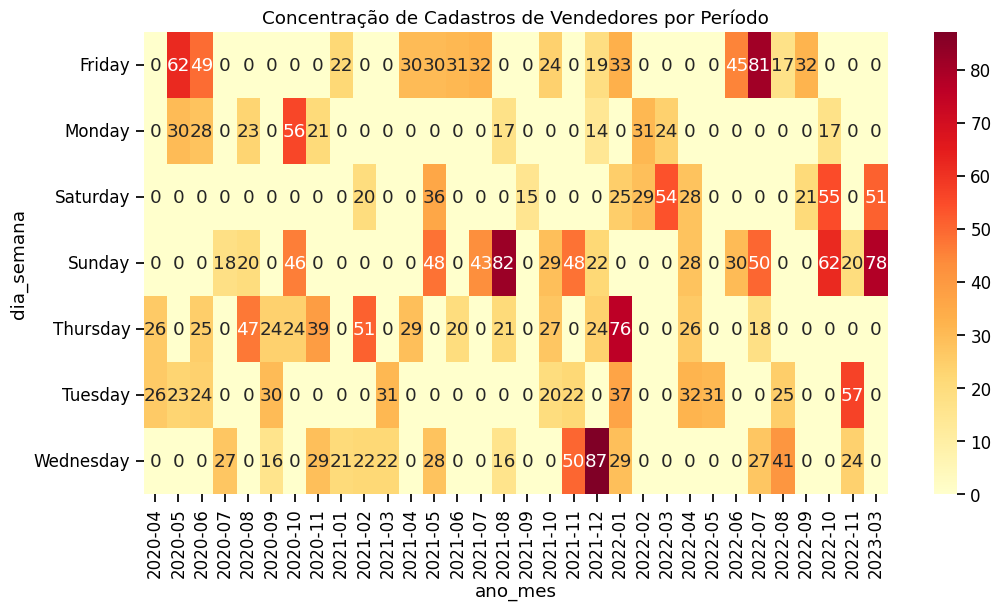

In [79]:
df_aval_sus_info['ano_mes'] = df_aval_sus_info['_data_cadastro_dt'].dt.to_period('M')
df_aval_sus_info['dia_semana'] = df_aval_sus_info['_data_cadastro_dt'].dt.day_name()

pivot_cluster = df_aval_sus_info.pivot_table(
    index='dia_semana', 
    columns='ano_mes', 
    values='vendedor_id', 
    aggfunc='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_cluster, annot=True, cmap='YlOrRd', fmt='g')
plt.title('Concentração de Cadastros de Vendedores por Período')
plt.show()
picos_mes = df_aval_sus_info.groupby('ano_mes').size()
meses_suspeitos = picos_mes[picos_mes > 50].index

In [80]:
df_aval_sus_info['is_cluster_cadastro'] = df_aval_sus_info['ano_mes'].isin(meses_suspeitos)
df_aval_sus_info[df_aval_sus_info['is_cluster_cadastro']]

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,_data_avaliacao_dt,_data_criacao_conta_dt,tempo_criacao_conta_dias,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt,ano_mes,dia_semana,is_cluster_cadastro
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,378,Loja EPNPN,2022-03-05,Salvador,PE,Casa & Decoração,1575,2.90,23,True,2022-03-05,2022-03,Saturday,True
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,277,Loja TTRVV,2021-12-30,Belo Horizonte,MA,Acessórios,1107,4.30,26,True,2021-12-30,2021-12,Thursday,True
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,189,Loja VLJBA,2020-11-25,Manaus,MG,Eletrônicos,278,3.80,10,True,2020-11-25,2020-11,Wednesday,True
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,356,Loja ZANLX,2020-09-10,Porto Alegre,MG,Esporte & Lazer,1765,4.30,18,False,2020-09-10,2020-09,Thursday,True
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,412,Loja AFRXX,2020-05-25,Brasília,RJ,Infantil,204,4.50,16,True,2020-05-25,2020-05,Monday,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,Sem Comentário Escrito,2023-12-26,2023-09-25,92,Loja ATTPS,2022-01-04,Belo Horizonte,PI,Infantil,680,4.10,18,False,2022-01-04,2022-01,Tuesday,True
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,1,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.80,2,False,2023-03-11,2023-03,Saturday,True
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,55,Loja YZZMG,2021-05-30,Belo Horizonte,PR,Moda Masculina,793,2.70,17,False,2021-05-30,2021-05,Sunday,True
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,136,Loja EPZCI,2022-03-07,Brasília,GO,Acessórios,1156,4.40,2,True,2022-03-07,2022-03,Monday,True


In [81]:
df_aval_sus_info['tempo_criacao_conta_dias'].describe()

count   3,000.00
mean      366.73
std       208.72
min         1.00
25%       188.00
50%       365.00
75%       548.00
max       730.00
Name: tempo_criacao_conta_dias, dtype: float64

In [82]:
df_nota_5 = df_aval_sus_info.query('nota == 5')
df_nota_5.query('verificado == False')['tempo_criacao_conta_dias'].describe()

count   635.00
mean    329.24
std     229.78
min       1.00
25%     122.00
50%     317.00
75%     527.50
max     730.00
Name: tempo_criacao_conta_dias, dtype: float64

In [83]:
df_nota_5 = df_aval_sus_info.query('nota == 5')
df_nota_5.query('verificado == True')['tempo_criacao_conta_dias'].describe()

count   555.00
mean    383.20
std     201.50
min      31.00
25%     205.50
50%     375.00
75%     554.00
max     729.00
Name: tempo_criacao_conta_dias, dtype: float64

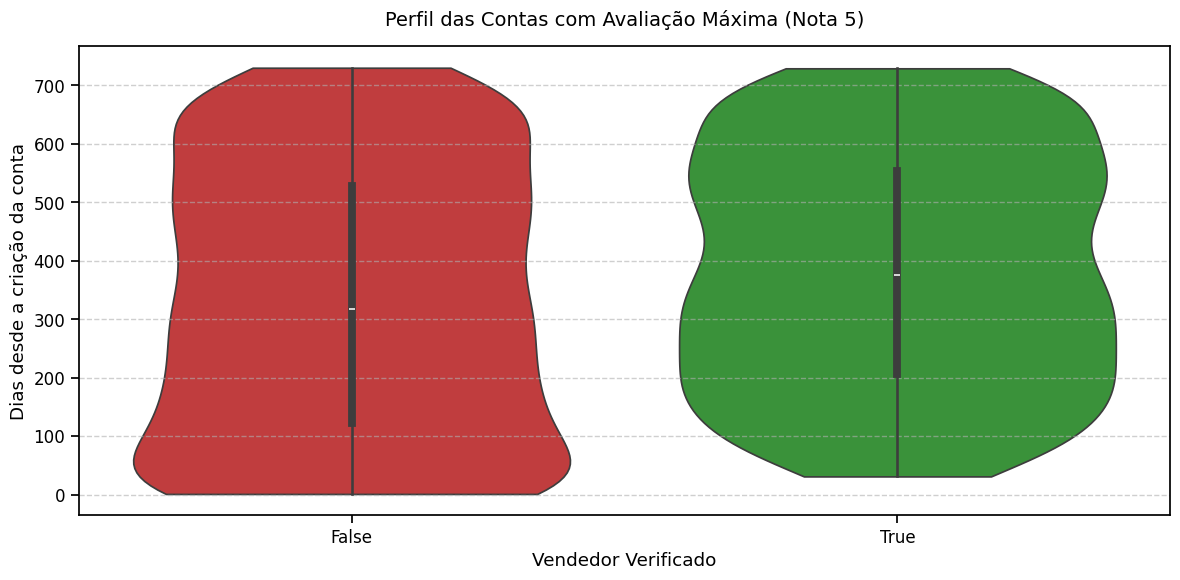

In [84]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='tempo_criacao_conta_dias', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [85]:
df_ips = df_nota_5.groupby(
    ['vendedor_id', 'verificado', 'ip_origem']
).size().reset_index(name='contagem_por_ip').sort_values('contagem_por_ip', ascending=False)

df_ips

,vendedor_id,verificado,ip_origem,contagem_por_ip
418,VEND-0043,False,192.168.1.100,9
432,VEND-0045,False,192.168.1.100,8
439,VEND-0046,False,192.168.1.100,7
434,VEND-0045,False,192.168.1.105,7
441,VEND-0046,False,192.168.1.105,7
...,...,...,...,...
1104,VEND-0118,True,133.72.164.70,1
1105,VEND-0118,True,191.108.215.174,1
1106,VEND-0118,True,222.233.32.202,1
1107,VEND-0118,True,24.230.35.3,1


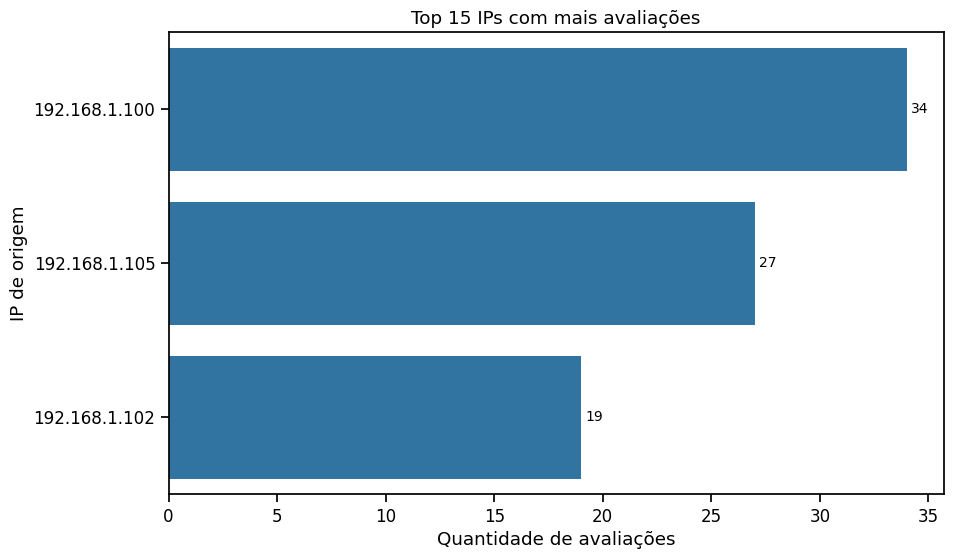

In [86]:
top_ips = df_ips.groupby('ip_origem')['contagem_por_ip'] \
    .sum() \
    .sort_values(ascending=False) \
    .reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_ips.query('contagem_por_ip > 1'),
    x='contagem_por_ip',
    y='ip_origem',
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Top 15 IPs com mais avaliações')
plt.xlabel('Quantidade de avaliações')
plt.ylabel('IP de origem')

plt.show()

In [87]:
ips_por_vendedor = df_ips.groupby(
    ['vendedor_id','verificado']
)['ip_origem'].nunique().reset_index(name='qtd_ips')
ips_por_vendedor

,vendedor_id,verificado,qtd_ips
0,VEND-0001,False,10
1,VEND-0002,False,8
2,VEND-0003,True,8
3,VEND-0004,False,9
4,VEND-0005,False,12
...,...,...,...
115,VEND-0116,True,14
116,VEND-0117,True,11
117,VEND-0118,True,11
118,VEND-0119,False,5


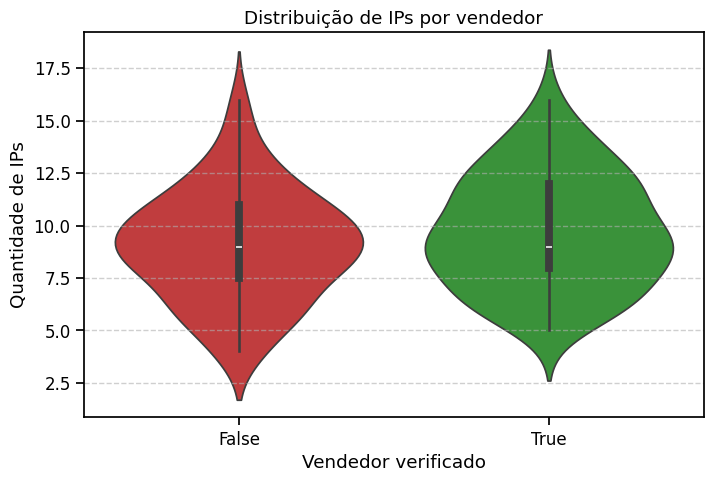

In [88]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=ips_por_vendedor,
    x='verificado',
    y='qtd_ips',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    legend=False
)

plt.title('Distribuição de IPs por vendedor')
plt.xlabel('Vendedor verificado')
plt.ylabel('Quantidade de IPs')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos

plt.show()

In [89]:
ips_por_vendedor.query('verificado == True')['qtd_ips'].describe()

count   57.00
mean     9.74
std      2.68
min      5.00
25%      8.00
50%      9.00
75%     12.00
max     16.00
Name: qtd_ips, dtype: float64

In [90]:
ips_por_vendedor.query('verificado == False')['qtd_ips'].describe()

count   63.00
mean     9.05
std      2.64
min      4.00
25%      7.50
50%      9.00
75%     11.00
max     16.00
Name: qtd_ips, dtype: float64

In [91]:
vendedores_por_ip_nao_verificado = df_ips.query('verificado == False').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')

ips_suspeitos = vendedores_por_ip_nao_verificado.sort_values(
    'qtd_vendedores',
    ascending=False
).reset_index(drop=True)

ips_suspeitos.head(10)

,ip_origem,qtd_vendedores
0,192.168.1.105,5
1,192.168.1.100,5
2,192.168.1.102,5
3,1.202.158.15,1
4,1.34.57.240,1
5,1.67.235.15,1
6,10.141.219.124,1
7,10.165.227.175,1
8,10.240.116.22,1
9,10.26.252.128,1


In [92]:
vendedores_por_ip_verificado = df_ips.query('verificado == True').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')

ips_n_suspeitos = vendedores_por_ip_verificado.sort_values(
    'qtd_vendedores',
    ascending=False
).reset_index(drop=True)

ips_n_suspeitos.head(10)

,ip_origem,qtd_vendedores
0,1.133.190.132,1
1,10.148.84.36,1
2,10.34.7.82,1
3,10.74.175.77,1
4,100.184.55.222,1
5,100.37.19.212,1
6,100.38.151.247,1
7,100.97.2.87,1
8,101.208.212.251,1
9,102.167.38.4,1


In [93]:
ips_comuns = ips_suspeitos.merge(
    ips_n_suspeitos,
    on='ip_origem',
    suffixes=('_nao_verificado', '_verificado')
)

ips_comuns.head()

,ip_origem,qtd_vendedores_nao_verificado,qtd_vendedores_verificado


In [94]:
df_textos = df_nota_5.groupby(
    ['texto_avaliacao', 'verificado'],
    dropna=False
).size().reset_index(name='contagem')

top_textos = df_textos.sort_values('contagem', ascending=False).head(15)
top_textos

,texto_avaliacao,verificado,contagem
5,Excelente custo-benefício.,False,78
17,"Recomendo, boa experiência.",True,75
10,Não gostei da qualidade.,True,74
21,"Veio com defeito, pedi troca.",False,65
14,"Produto ok, dentro do esperado.",False,63
1,Bom produto pelo preço.,True,61
12,Produto diferente da foto.,True,61
9,Não gostei da qualidade.,False,61
15,"Produto ok, dentro do esperado.",True,61
16,"Recomendo, boa experiência.",False,60


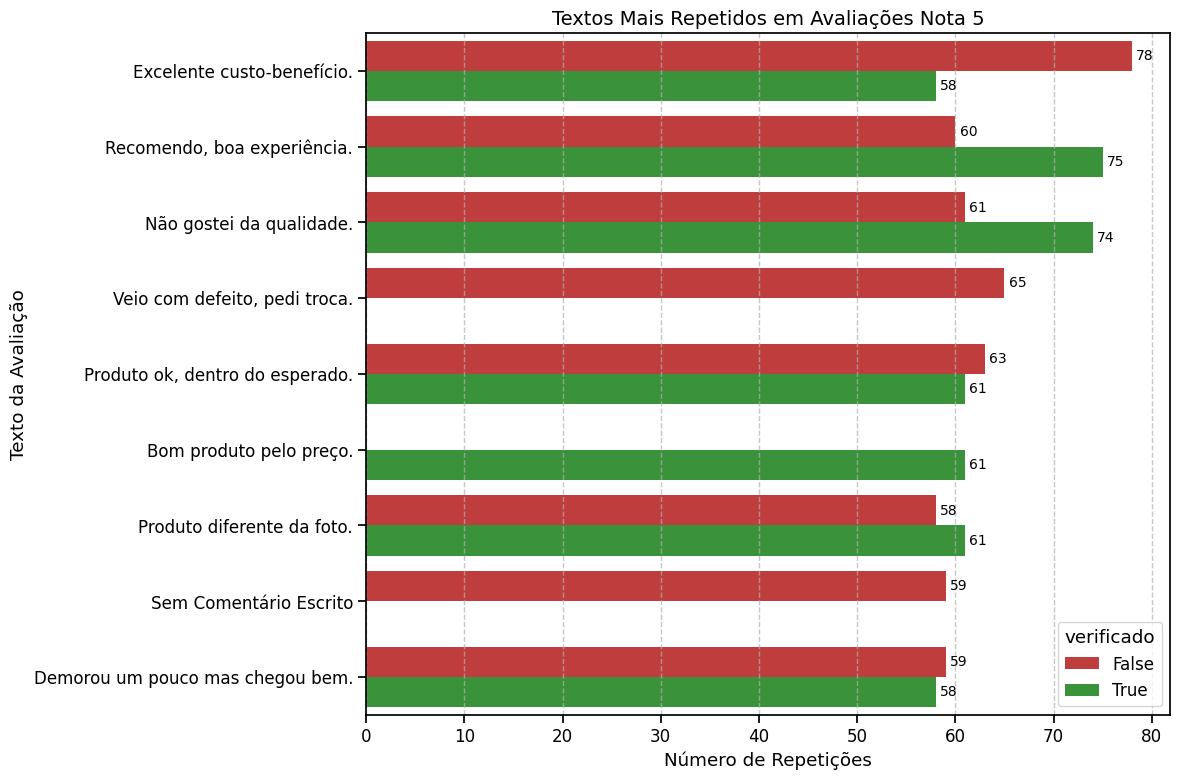

In [95]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_textos,
    x='contagem',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)


for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Textos Mais Repetidos em Avaliações Nota 5', fontsize=14)
plt.xlabel('Número de Repetições')
plt.ylabel('Texto da Avaliação')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [96]:
df_categorias = df_nota_5.groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem')

df_categorias = df_categorias.sort_values('contagem', ascending=False)
df_categorias

,categoria_principal,verificado,contagem
5,Casa & Decoração,True,128
8,Esporte & Lazer,False,119
4,Casa & Decoração,False,92
15,Moda Masculina,True,91
12,Moda Feminina,False,90
6,Eletrônicos,False,84
9,Esporte & Lazer,True,80
14,Moda Masculina,False,73
11,Infantil,True,66
10,Infantil,False,65


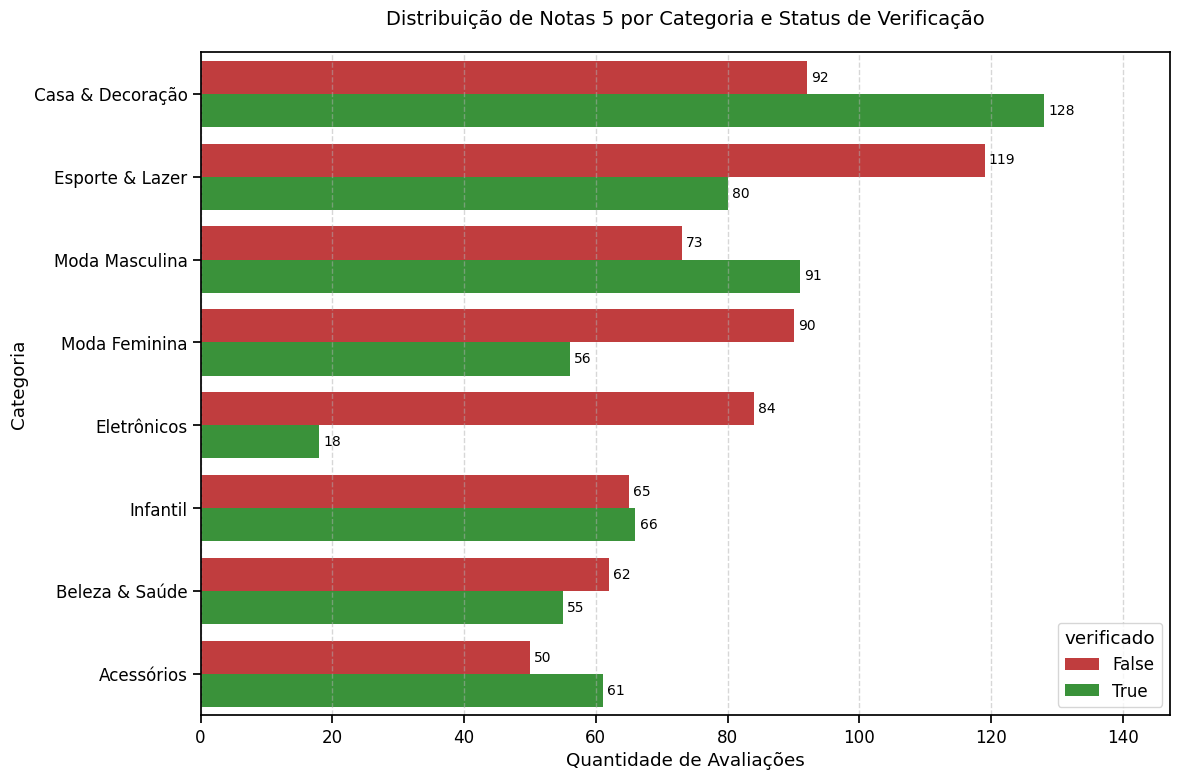

In [97]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_categorias,
    x='contagem',
    y='categoria_principal',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'} 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Distribuição de Notas 5 por Categoria e Status de Verificação', fontsize=14, pad=20)
plt.xlabel('Quantidade de Avaliações')
plt.ylabel('Categoria')

plt.xlim(0, df_categorias['contagem'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

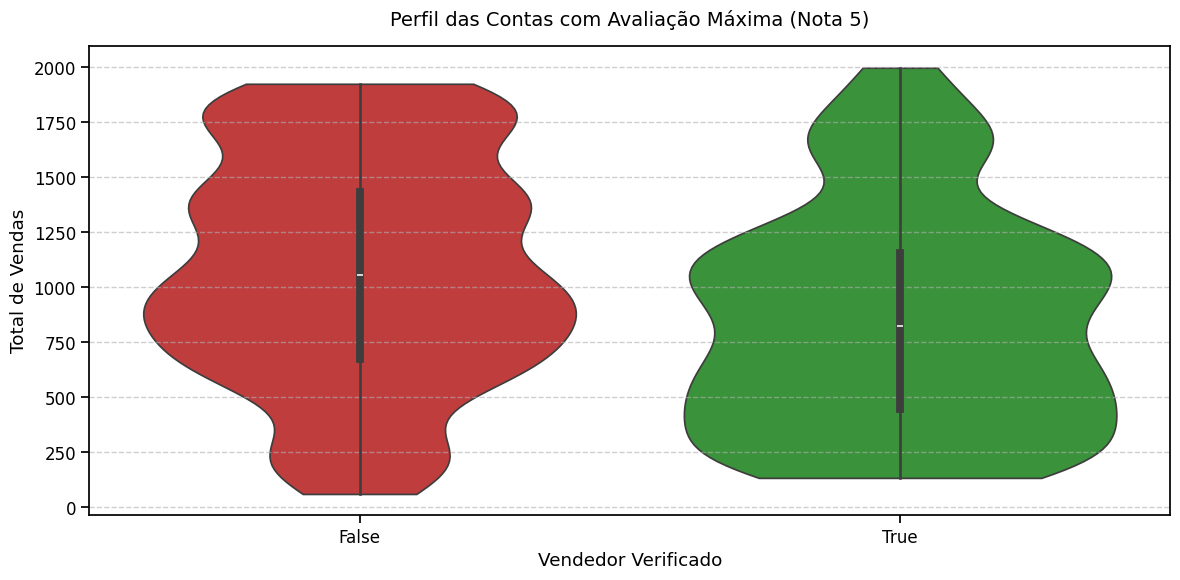

In [98]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='total_vendas', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

# Estilização extra
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos
plt.ylabel('Total de Vendas')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

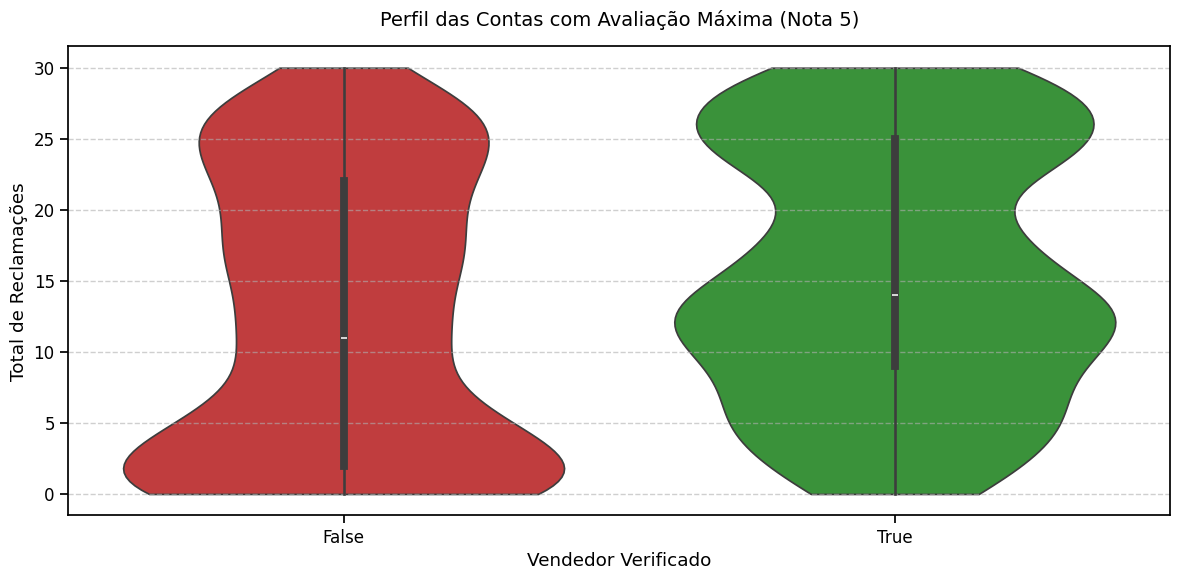

In [99]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='reclamacoes', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Total de Reclamações')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

**Conclusão:**

---
### 3. **Os vendedores suspeitos compartilham características em comum?**

**Conclusão:**

---
4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

**Conclusão:**

---
5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

**Conclusão:**

---
6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?

**Conclusão:**

## Regras automáticas

1. **Horário irrelevante até o momento**: ...